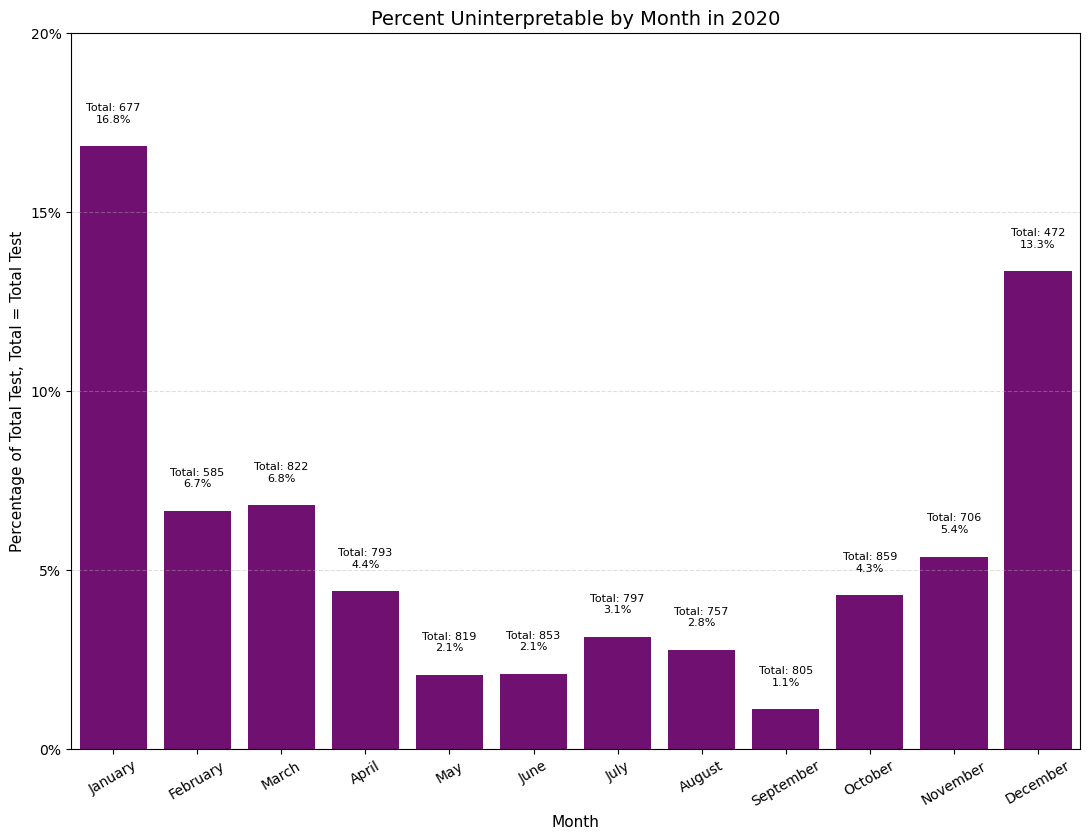

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Read data
df = pd.read_csv("Taina Sakagawa Microcredential/Microcredential_Data.csv")

# Prepare data
counts = df.groupby(["ORDMONTH", "RESULT"]).size().reset_index(name="count")

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

counts["ORDMONTH"] = pd.Categorical(counts["ORDMONTH"], categories=month_order, ordered=True)
counts = counts.sort_values("ORDMONTH")

# Totals and percentages
counts["total"] = counts.groupby("ORDMONTH")["count"].transform("sum")
counts["percent"] = (counts["count"] / counts["total"]) * 100

# Filter only Uninterpretable
filtered = counts[counts["RESULT"] == "Uninterpretable"].reset_index(drop=True)

# BarPlot
plt.figure(figsize=(11,8.5))
ax = sns.barplot(data=filtered, x="ORDMONTH", y="percent", color="purple")

plt.title("Percent Uninterpretable by Month in 2020", fontsize=14)
plt.xlabel("Month", fontsize=11)
plt.ylabel("Percentage of Total Test, Total = Total Test", fontsize=11)
plt.xticks(rotation=30, fontsize=10)

# Dynamic Y-axis (max + 2%)
max_percent = filtered["percent"].max()
y_max = max_percent + 2
y_max = int(np.ceil(y_max / 5.0)) * 5
y_max = max(10, y_max)

ax.set_ylim(0, y_max)
ax.set_yticks(range(0, y_max + 1, 5))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}%"))

# Labels above bars
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    if height == 0:
        continue
    
    row = filtered.iloc[i]
    x = bar.get_x() + bar.get_width() / 2

    ax.text(
        x,
        height + (y_max * 0.03),  # dynamic spacing
        f'Total: {int(row["total"])}\n{row["percent"]:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8
    )

# Grid for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("Percent Uninterpretables by Month.png", dpi=300)
plt.show()

In [2]:
counts

,ORDMONTH,RESULT,count,total,percent
19,January,Uninterpretable,114,677,16.838996
18,January,Normal,542,677,80.059084
17,January,Borderline,17,677,2.511078
16,January,Abnormal,4,677,0.590842
15,February,Uninterpretable,39,585,6.666667
14,February,Normal,518,585,88.547009
13,February,Borderline,24,585,4.102564
12,February,Abnormal,4,585,0.683761
28,March,Abnormal,13,822,1.581509
31,March,Uninterpretable,56,822,6.812652
